In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv(r'Unemployment in India.csv')
df.head(10)

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural
5,Andhra Pradesh,31-10-2019,Monthly,3.52,12017412.0,43.01,Rural
6,Andhra Pradesh,30-11-2019,Monthly,4.12,11397681.0,41.00,Rural
7,Andhra Pradesh,31-12-2019,Monthly,4.38,12528395.0,45.14,Rural
8,Andhra Pradesh,31-01-2020,Monthly,4.84,12016676.0,43.46,Rural
9,Andhra Pradesh,29-02-2020,Monthly,5.91,11723617.0,42.83,Rural


In [3]:
df.shape

(768, 7)

In [4]:
df.columns = df.columns.str.strip()

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   Region                                   740 non-null    object 
 1   Date                                     740 non-null    object 
 2   Frequency                                740 non-null    object 
 3   Estimated Unemployment Rate (%)          740 non-null    float64
 4   Estimated Employed                       740 non-null    float64
 5   Estimated Labour Participation Rate (%)  740 non-null    float64
 6   Area                                     740 non-null    object 
dtypes: float64(3), object(4)
memory usage: 42.1+ KB


In [6]:
df['Frequency'].unique()

array([' Monthly', nan, 'Monthly'], dtype=object)

In [7]:
df['Frequency'] = df['Frequency'].str.strip()

In [8]:
df['Frequency'].unique()

array(['Monthly', nan], dtype=object)

In [9]:
df['Region'].unique()

array(['Andhra Pradesh', 'Assam', 'Bihar', 'Chhattisgarh', 'Delhi', 'Goa',
       'Gujarat', 'Haryana', 'Himachal Pradesh', 'Jammu & Kashmir',
       'Jharkhand', 'Karnataka', 'Kerala', 'Madhya Pradesh',
       'Maharashtra', 'Meghalaya', 'Odisha', 'Puducherry', 'Punjab',
       'Rajasthan', 'Sikkim', 'Tamil Nadu', 'Telangana', 'Tripura',
       'Uttar Pradesh', 'Uttarakhand', 'West Bengal', nan, 'Chandigarh'],
      dtype=object)

In [10]:
df['Area'].unique()

array(['Rural', nan, 'Urban'], dtype=object)

In [11]:
df.dropna(inplace=True)

In [12]:
df.isnull().sum()

Region                                     0
Date                                       0
Frequency                                  0
Estimated Unemployment Rate (%)            0
Estimated Employed                         0
Estimated Labour Participation Rate (%)    0
Area                                       0
dtype: int64

In [13]:
df.duplicated().sum()

np.int64(0)

In [14]:
df_date = df.groupby('Date')['Estimated Unemployment Rate (%)'].sum().reset_index()

In [15]:
df_date

,Date,Estimated Unemployment Rate (%)
0,29-02-2020,528.13
1,30-04-2020,1205.72
2,30-06-2019,502.38
3,30-06-2020,595.18
4,30-09-2019,470.69
5,30-11-2019,542.76
6,31-01-2020,527.39
7,31-03-2020,556.43
8,31-05-2019,479.21
9,31-05-2020,1268.64


In [16]:
df_date['Date'] = pd.to_datetime(df['Date'])

In [17]:
df_date.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14 entries, 0 to 13
Data columns (total 2 columns):
 #   Column                           Non-Null Count  Dtype         
---  ------                           --------------  -----         
 0   Date                             14 non-null     datetime64[ns]
 1   Estimated Unemployment Rate (%)  14 non-null     float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 356.0 bytes


In [18]:
df_date.reset_index(drop=True,inplace=True)

In [19]:
df_date.set_index('Date',inplace=True)

In [20]:
df_date.sort_index(inplace=True)
df_date

,Estimated Unemployment Rate (%)
Date,
2019-05-31,528.13
2019-06-30,1205.72
2019-07-31,502.38
2019-08-31,595.18
2019-09-30,470.69
2019-10-31,542.76
2019-11-30,527.39
2019-12-31,556.43
2020-01-31,479.21


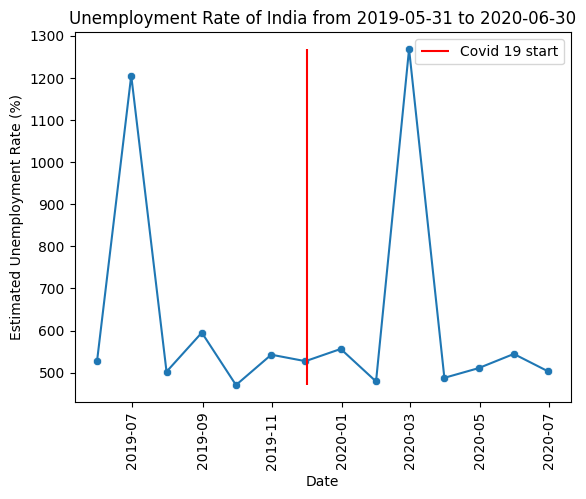

In [21]:
sns.lineplot(data=df_date,x=df_date.index,y='Estimated Unemployment Rate (%)')
sns.scatterplot(data=df_date,x=df_date.index,y='Estimated Unemployment Rate (%)')
plt.title("Unemployment Rate of India from 2019-05-31 to 2020-06-30")
date_line = pd.to_datetime("2019-12-1")
plt.vlines(x= date_line,ymin=df_date['Estimated Unemployment Rate (%)'].min(),ymax=df_date['Estimated Unemployment Rate (%)'].max(),color='red',label='Covid 19 start')
plt.xticks(rotation=90)
plt.legend()
plt.show()

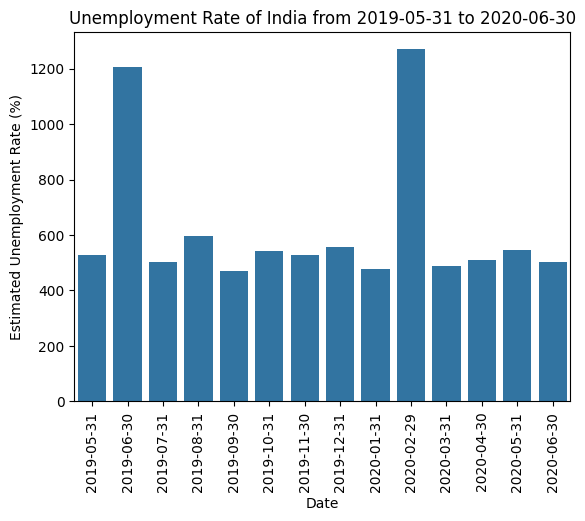

In [22]:
sns.barplot(data=df_date,x=df_date.index,y='Estimated Unemployment Rate (%)')
plt.title("Unemployment Rate of India from 2019-05-31 to 2020-06-30")
plt.xticks(rotation=90)
plt.show()

In [23]:
df

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural
...,...,...,...,...,...,...,...
749,West Bengal,29-02-2020,Monthly,7.55,10871168.0,44.09,Urban
750,West Bengal,31-03-2020,Monthly,6.67,10806105.0,43.34,Urban
751,West Bengal,30-04-2020,Monthly,15.63,9299466.0,41.20,Urban
752,West Bengal,31-05-2020,Monthly,15.22,9240903.0,40.67,Urban


In [24]:
df.columns

Index(['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)',
       'Estimated Employed', 'Estimated Labour Participation Rate (%)',
       'Area'],
      dtype='object')

In [25]:
df['Date'] = pd.to_datetime(df['Date'])

In [26]:
covid_df = df[df['Date'] > pd.to_datetime('2019-11-30')]

In [27]:
covid_df

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
7,Andhra Pradesh,2019-12-31,Monthly,4.38,12528395.0,45.14,Rural
8,Andhra Pradesh,2020-01-31,Monthly,4.84,12016676.0,43.46,Rural
9,Andhra Pradesh,2020-02-29,Monthly,5.91,11723617.0,42.83,Rural
10,Andhra Pradesh,2020-03-31,Monthly,4.06,11359660.0,40.66,Rural
11,Andhra Pradesh,2020-04-30,Monthly,16.29,8792827.0,36.03,Rural
...,...,...,...,...,...,...,...
749,West Bengal,2020-02-29,Monthly,7.55,10871168.0,44.09,Urban
750,West Bengal,2020-03-31,Monthly,6.67,10806105.0,43.34,Urban
751,West Bengal,2020-04-30,Monthly,15.63,9299466.0,41.20,Urban
752,West Bengal,2020-05-31,Monthly,15.22,9240903.0,40.67,Urban


In [28]:
df_state = df.groupby('Region')['Estimated Unemployment Rate (%)'].sum().reset_index()
df_state.sort_values('Estimated Unemployment Rate (%)',ascending=False)

,Region,Estimated Unemployment Rate (%)
24,Tripura,793.81
8,Haryana,735.93
11,Jharkhand,576.38
2,Bihar,529.71
9,Himachal Pradesh,519.13
5,Delhi,461.87
20,Rajasthan,393.63
25,Uttar Pradesh,351.44
10,Jammu & Kashmir,339.96
19,Punjab,336.87


In [29]:
df_state_cov = covid_df.groupby('Region')['Estimated Unemployment Rate (%)'].sum().reset_index()
df_state_cov.sort_values('Estimated Unemployment Rate (%)',ascending=False)

,Region,Estimated Unemployment Rate (%)
8,Haryana,424.36
24,Tripura,400.01
11,Jharkhand,385.80
2,Bihar,332.66
5,Delhi,269.90
9,Himachal Pradesh,258.88
18,Puducherry,245.60
20,Rajasthan,228.81
22,Tamil Nadu,222.72
25,Uttar Pradesh,198.03


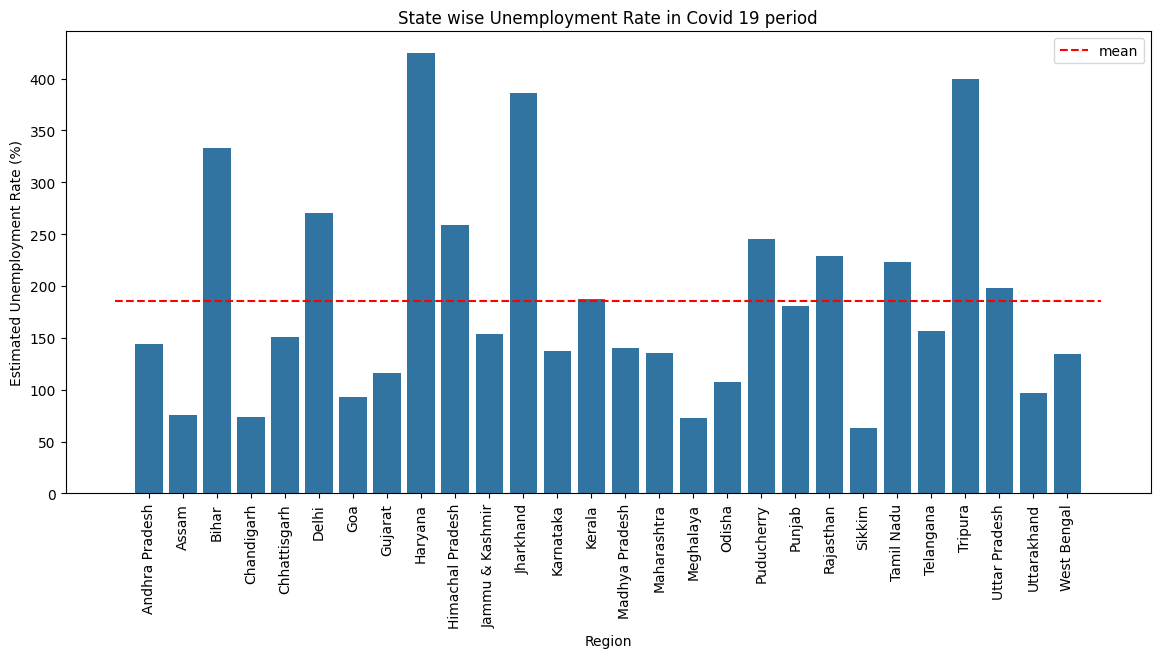

In [30]:
plt.figure(figsize=(14,6))
sns.barplot(data=df_state_cov,x='Region',y='Estimated Unemployment Rate (%)')
plt.title("State wise Unemployment Rate in Covid 19 period")
plt.hlines(y=df_state_cov['Estimated Unemployment Rate (%)'].mean(), xmin=-1, xmax=df_state.shape[0], colors='red', linestyles='dashed',label='mean')
plt.xticks(rotation = 90)
plt.legend()
plt.show()

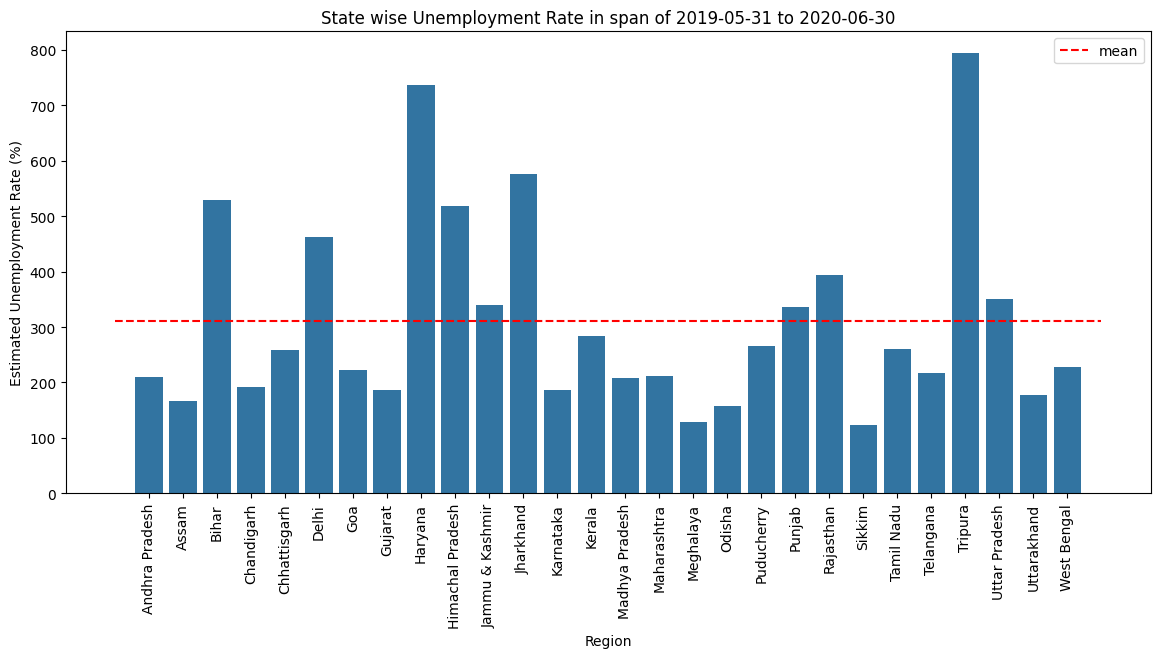

In [31]:
plt.figure(figsize=(14,6))
sns.barplot(data=df_state,x='Region',y='Estimated Unemployment Rate (%)')
plt.title("State wise Unemployment Rate in span of 2019-05-31 to 2020-06-30")
plt.hlines(y=df_state['Estimated Unemployment Rate (%)'].mean(), xmin=-1, xmax=df_state.shape[0], colors='red', linestyles='dashed',label='mean')
plt.xticks(rotation = 90)
plt.legend()
plt.show()

In [32]:
# Tripura, Haryana, and Jharkhand are the states with highest unemployement rate 

In [33]:
df['Region'].unique()

array(['Andhra Pradesh', 'Assam', 'Bihar', 'Chhattisgarh', 'Delhi', 'Goa',
       'Gujarat', 'Haryana', 'Himachal Pradesh', 'Jammu & Kashmir',
       'Jharkhand', 'Karnataka', 'Kerala', 'Madhya Pradesh',
       'Maharashtra', 'Meghalaya', 'Odisha', 'Puducherry', 'Punjab',
       'Rajasthan', 'Sikkim', 'Tamil Nadu', 'Telangana', 'Tripura',
       'Uttar Pradesh', 'Uttarakhand', 'West Bengal', 'Chandigarh'],
      dtype=object)

In [34]:
Tripura_df = df[df['Region']=='Tripura']
Haryana_df = df[df['Region']=='Haryana']
Jharkhand_df = df[df['Region']=='Jharkhand']

In [35]:
Tripura_df['Date'] = pd.to_datetime(Tripura_df['Date'])
Haryana_df['Date'] = pd.to_datetime(Haryana_df['Date'])
Jharkhand_df['Date'] = pd.to_datetime(Jharkhand_df['Date'])

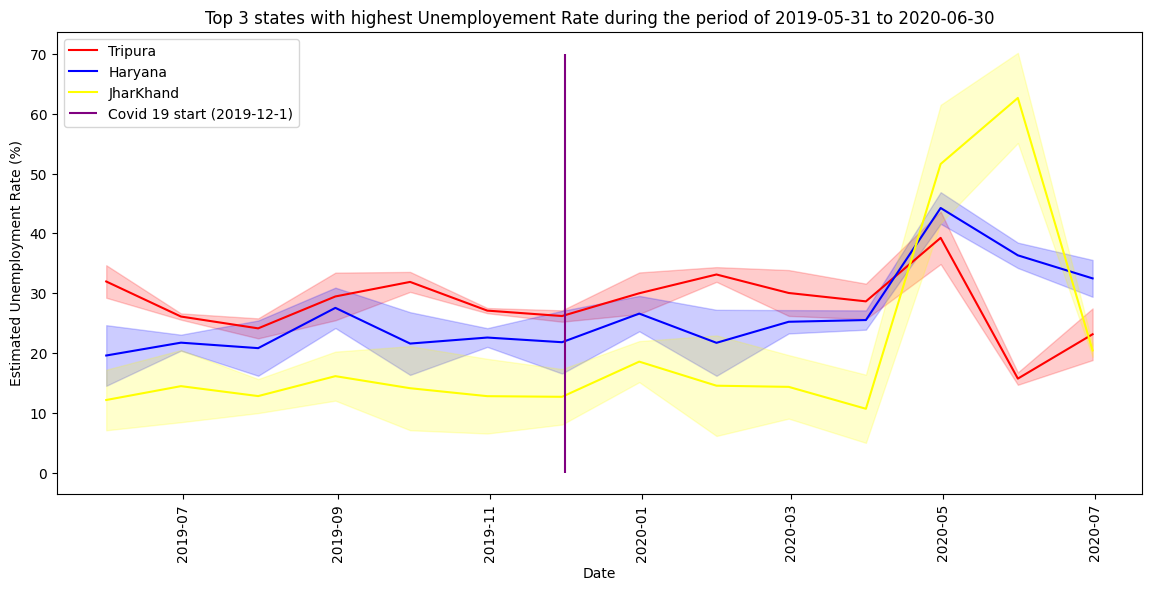

In [36]:
plt.figure(figsize=(14,6))
sns.lineplot(data=Tripura_df,x='Date',y='Estimated Unemployment Rate (%)',color='red',label='Tripura')
sns.lineplot(data=Haryana_df,x='Date',y='Estimated Unemployment Rate (%)',color='blue',label='Haryana')
sns.lineplot(data=Jharkhand_df,x='Date',y='Estimated Unemployment Rate (%)',color='yellow',label='JharKhand')
date_line = pd.to_datetime("2019-12-1")
plt.vlines(x= date_line,ymin=0,ymax=70,color='purple',label='Covid 19 start (2019-12-1)')
plt.title("Top 3 states with highest Unemployement Rate during the period of 2019-05-31 to 2020-06-30")
plt.xticks(rotation= 90)
plt.legend()
plt.show()

In [37]:
covid_df['Region'].value_counts()

Region
Andhra Pradesh      14
Bihar               14
Chhattisgarh        14
Delhi               14
Karnataka           14
Gujarat             14
Haryana             14
Himachal Pradesh    14
Jharkhand           14
Maharashtra         14
Madhya Pradesh      14
Kerala              14
West Bengal         14
Uttar Pradesh       14
Tripura             14
Odisha              14
Rajasthan           14
Punjab              14
Telangana           14
Tamil Nadu          14
Uttarakhand         13
Meghalaya           13
Assam               12
Puducherry          12
Jammu & Kashmir     10
Goa                 10
Sikkim               8
Chandigarh           5
Name: count, dtype: int64

In [38]:
Tripura_df_cov = covid_df[df['Region']=='Tripura']
Haryana_df_cov = covid_df[df['Region']=='Haryana']
Hp_df_cov = covid_df[df['Region']=='Himachal Pradesh']

In [39]:
Tripura_df_cov['Date'] = pd.to_datetime(Tripura_df_cov['Date'])
Haryana_df_cov['Date'] = pd.to_datetime(Haryana_df_cov['Date'])
Hp_df_cov['Date'] = pd.to_datetime(Hp_df_cov['Date'])

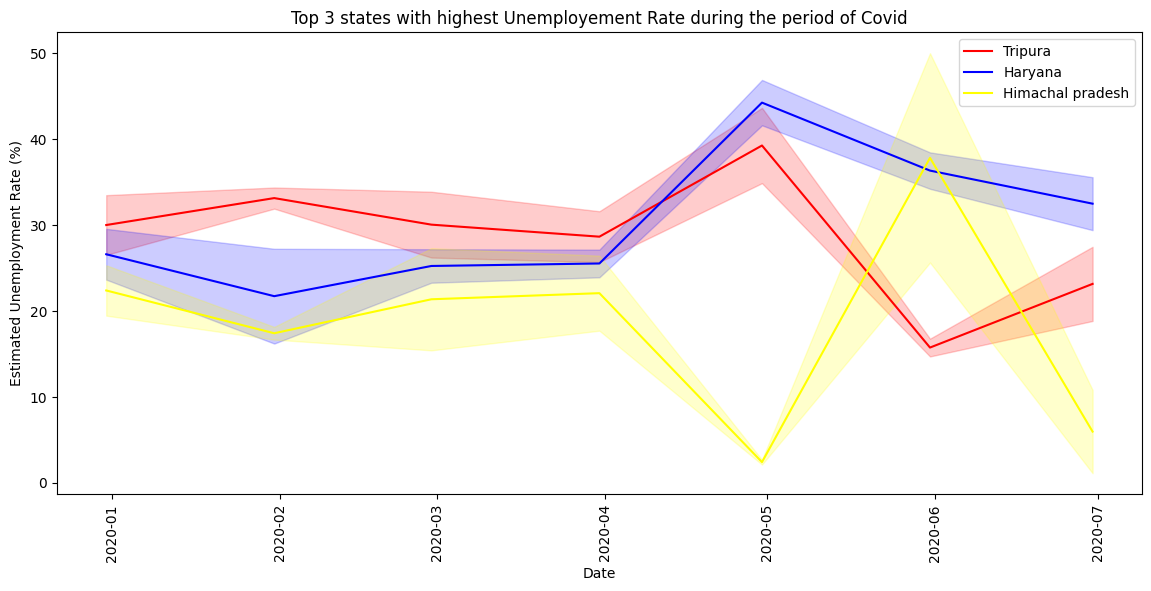

In [40]:
plt.figure(figsize=(14,6))
sns.lineplot(data=Tripura_df_cov,x='Date',y='Estimated Unemployment Rate (%)',color='red',label='Tripura')
sns.lineplot(data=Haryana_df_cov,x='Date',y='Estimated Unemployment Rate (%)',color='blue',label='Haryana')
sns.lineplot(data=Hp_df_cov,x='Date',y='Estimated Unemployment Rate (%)',color='yellow',label='Himachal pradesh')
plt.title("Top 3 states with highest Unemployement Rate during the period of Covid")
plt.xticks(rotation= 90)
plt.legend()
plt.show()